In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, log_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.benchmark as benchmark
import torch._dynamo
from torchinfo import summary
import seaborn as sns

In [2]:
torch._dynamo.config.cache_size_limit = 16 # type: ignore

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device = "cpu"

In [3]:
df = sns.load_dataset('diamonds')
df = df[['carat', 'depth', 'table', 'price', 'x', 'y', 'z', 'cut']]

df['cut'] = (df['cut'] == 'Ideal').astype(int)

X = df.drop('cut', axis=1)
y = df['cut']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long).to(device)

print(X.shape)
print(y.shape)

ideal_percentage = df['cut'].mean() * 100
print(f"Percentage of diamonds with 'Ideal' cut: {ideal_percentage:.2f}%")

model = LogisticRegression(penalty='l2', C=0.001, max_iter=10000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

y_pred_proba = model.predict_proba(X_test)
loss = log_loss(y_test, y_pred_proba)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Ideal', 'Ideal']))
print(model.coef_)
print(f"Log Loss: {loss:.6f}")

(53940, 7)
(53940,)
Percentage of diamonds with 'Ideal' cut: 39.95%
Test Accuracy: 79.30%
Classification Report:
              precision    recall  f1-score   support

   Not Ideal       0.82      0.85      0.83      6496
       Ideal       0.75      0.71      0.73      4292

    accuracy                           0.79     10788
   macro avg       0.79      0.78      0.78     10788
weighted avg       0.79      0.79      0.79     10788

[[-0.15688782 -0.46189194 -1.57368125  0.22509094 -0.08309788 -0.03167662
  -0.08671039]]
Log Loss: 0.451068


/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered

In [4]:
def train(model, criterion, optimizer):
    print(summary(model, input_data=X_train_tensor))

    torch.set_printoptions(threshold=float('inf'))
    for name, param in model.named_parameters():
        print(name)
        print(param)

    @torch._dynamo.explain
    def run_model(x):
        return model(x)

    run_model(X_train_tensor) # type: ignore

    epochs = 10000
    best_test_loss = float('inf')

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        train_outputs = model(X_train_tensor)
        train_loss = criterion(train_outputs, y_train_tensor)
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test_tensor)
            test_loss = criterion(test_outputs, y_test_tensor)
            test_predictions = torch.argmax(test_outputs, dim=1)
            test_accuracy = (test_predictions == y_test_tensor).sum().item() / y_test_tensor.size(0)

        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())

        if test_loss.item() < best_test_loss:
            best_test_loss = test_loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss.item():.8f}, Test Loss: {test_loss.item():.8f}, Test Accuracy: {test_accuracy:.4f}")

    print()
    print(f"Lowest Test Loss: {best_test_loss:.8f}")

    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Test Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

In [5]:
class DiamondNN(nn.Module):
    def __init__(self, n, num_layers=4):
        super().__init__()
        self.bias = torch.nn.Parameter(torch.zeros(n))

        self.linears = nn.ModuleList()
        for i in range(num_layers):
            self.linears.append(nn.Linear(n * 2 * (2**i), n * (2**i)))

            with torch.no_grad():
                nn.init.zeros_(self.linears[i].weight) # type: ignore
                nn.init.zeros_(self.linears[i].bias)   # type: ignore

        self.final = nn.Linear(n * 2 * (2**num_layers) , 1)

        with torch.no_grad():
            nn.init.zeros_(self.final.weight)
            nn.init.zeros_(self.final.bias)

    def forward(self, x):
        x = x + self.bias

        for linear in self.linears:
            pos = F.relu(x)
            neg = F.relu(-x)
            
            new_x = linear(torch.cat([pos, neg], dim=-1)) + x
            x = torch.cat([new_x, x], dim=-1)

        pos = F.relu(x)
        neg = F.relu(-x)

        x = self.final(torch.cat([pos, neg], dim=-1))
        return torch.cat([x, -x], dim=-1)

In [6]:
model = torch.compile(DiamondNN(n=X.shape[1]).to(device))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) # type: ignore

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─DiamondNN: 1-1                         [43152, 2]                7
│    └─ModuleList: 2-1                   --                        --
│    │    └─Linear: 3-1                  [43152, 7]                105
│    │    └─Linear: 3-2                  [43152, 14]               406
│    │    └─Linear: 3-3                  [43152, 28]               1,596
│    │    └─Linear: 3-4                  [43152, 56]               6,328
│    └─Linear: 2-2                       [43152, 1]                225
Total params: 8,667
Trainable params: 8,667
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 373.70
Input size (MB): 1.21
Forward/backward pass size (MB): 36.59
Params size (MB): 0.03
Estimated Total Size (MB): 37.84
_orig_mod.bias
Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0.], requires_grad=True)
_orig_mod.linears.0.weight
Parameter

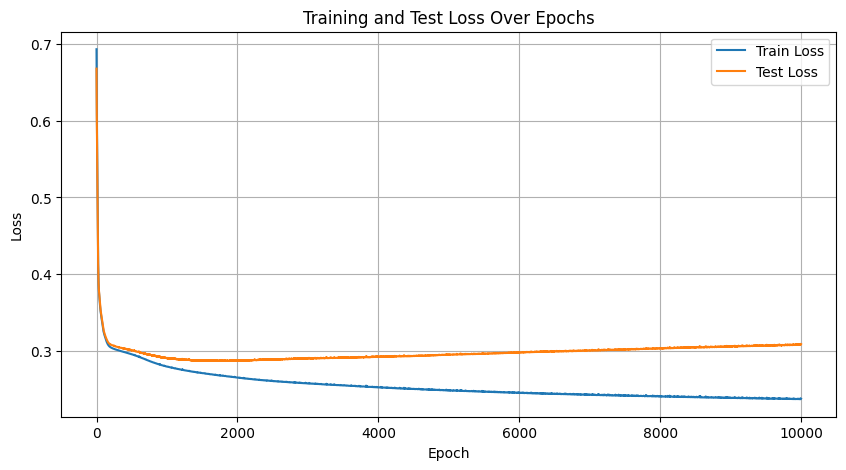

In [7]:
train(model, criterion, optimizer)

_orig_mod.bias
Parameter containing:
tensor([-0.1168, -0.0656,  0.0692, -0.1146,  0.0727,  0.0825, -0.1335],
       requires_grad=True)
_orig_mod.linears.0.weight
Parameter containing:
tensor([[ 0.4105,  0.0605,  0.0091, -0.1182, -0.2403, -0.0274, -0.0462, -0.0932,
          0.1274,  0.0473, -0.0096,  0.1353, -0.0249,  0.0820],
        [-0.0265,  0.3262,  0.0724, -0.0104, -0.1445, -0.0047,  0.2205, -0.0197,
         -0.2697, -0.0599, -0.0756,  0.2283, -0.2679, -0.0326],
        [ 0.0995, -0.0201,  0.3905, -0.0305, -0.0789,  0.0555, -0.0437, -0.0075,
         -0.0089, -0.3539,  0.0613,  0.0973, -0.1297,  0.0318],
        [ 0.1471, -0.0526, -0.1268,  0.3233, -0.2334,  0.5395,  0.0249,  0.0471,
          0.0327,  0.0517, -0.1161, -0.0094,  0.0165, -0.0277],
        [-0.0698,  0.0559,  0.0646, -0.0460,  0.2813, -0.2567,  0.0104, -0.0347,
         -0.1620, -0.0865,  0.0619, -0.2718,  0.2850, -0.0288],
        [-0.1407, -0.0402,  0.0685, -0.0333, -0.1926,  0.3460, -0.0430, -0.0404,
         

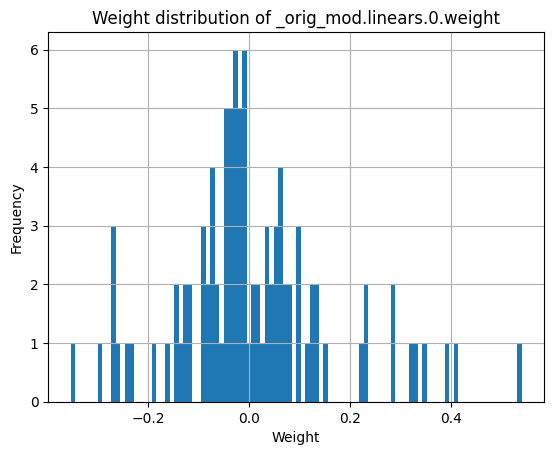

_orig_mod.linears.0.bias
Parameter containing:
tensor([-0.1071, -0.3648,  0.1439, -0.0172,  0.0945,  0.2080, -0.1945],
       requires_grad=True)
_orig_mod.linears.1.weight
Parameter containing:
tensor([[-1.0737e-01,  2.2452e-01,  2.8608e-01,  2.9967e-02, -3.1940e-01,
          2.2996e-02, -1.5131e-01,  3.0527e-02, -8.3423e-03,  1.8801e-01,
          6.1939e-02, -2.7486e-01, -8.3925e-02, -1.5697e-01, -2.0764e-01,
          3.0524e-02,  7.8607e-03, -3.3806e-02,  1.7099e-01, -1.5574e-03,
          6.8088e-02, -1.0193e-01,  3.6844e-02, -3.0267e-02, -1.9116e-02,
          1.5225e-01, -3.4151e-02,  9.0769e-02],
        [-1.8653e-02,  1.1841e-01,  4.0174e-01, -1.1699e-01, -1.2232e-01,
         -3.1767e-01,  7.5390e-01, -1.1095e-01,  1.1888e-02, -1.0442e-02,
          1.1810e-01, -1.9946e-01, -2.0522e-01,  1.5340e-01,  4.7497e-02,
         -9.2120e-02,  9.1482e-02, -4.8836e-02,  9.3162e-01, -7.3236e-01,
          8.6587e-02,  1.1847e-01,  1.1730e-01, -2.8971e-02,  1.4385e-01,
          5.8584

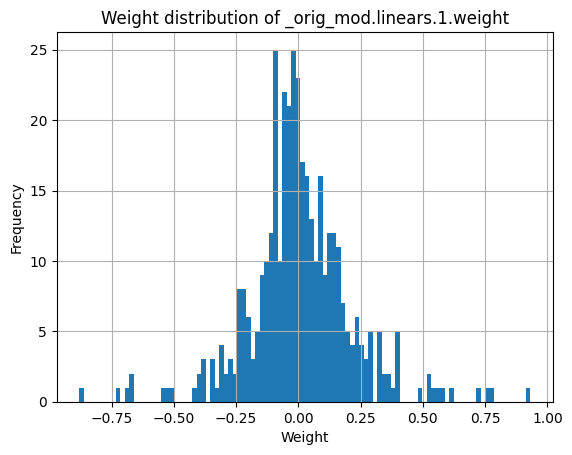

_orig_mod.linears.1.bias
Parameter containing:
tensor([-0.0314, -0.6652,  0.4087,  0.0948,  0.1037,  0.0229, -0.4982, -0.0724,
         0.2009, -0.1553, -0.2078,  0.1655,  0.0554,  0.0544],
       requires_grad=True)
_orig_mod.linears.2.weight
Parameter containing:
tensor([[-2.4963e-01,  1.4082e+00,  3.4733e-01,  2.9738e-02, -8.6963e-02,
          2.1341e-01, -3.0482e-02,  2.5647e-02,  2.4687e-01,  3.8765e-01,
         -3.9512e-02, -1.6679e-01,  8.0247e-02,  9.9125e-02, -2.3044e-01,
          2.3199e-01,  2.7568e-01,  7.0936e-02, -2.1581e-01,  6.1705e-02,
         -2.4071e-02, -6.5581e-02,  3.4582e-02,  1.9381e-01,  6.2575e-02,
         -2.0898e-01, -3.9921e-02, -8.8364e-02, -1.7260e-01,  6.7522e-02,
          2.5359e-02,  6.9058e-02,  3.0334e-01, -1.7002e-01,  5.5473e-02,
         -4.1875e-02, -9.2713e-02,  6.9143e-02,  4.7858e-02,  1.3217e-01,
         -7.6586e-02,  6.1981e-02, -1.0881e-01, -3.4184e-02,  4.1809e-02,
          2.1425e-02,  8.2810e-02, -1.2060e-01,  9.5227e-02, -2.3367

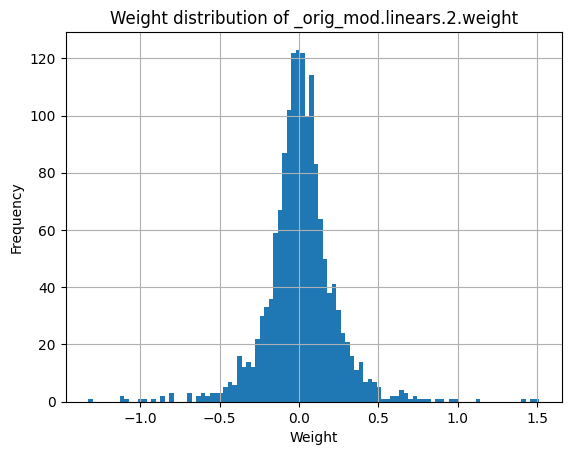

_orig_mod.linears.2.bias
Parameter containing:
tensor([ 0.0462,  0.1099,  0.4222, -0.0900, -0.1540, -0.0353, -0.2035, -0.0512,
        -0.1983,  0.4657, -0.2112, -0.0281, -0.0352, -0.0020, -0.1029, -0.1120,
         0.4049, -0.0038,  0.0350,  0.2033, -0.1206, -0.0809, -0.0161, -0.2987,
        -0.0056, -0.1331,  0.2350, -0.1009], requires_grad=True)
_orig_mod.linears.3.weight
Parameter containing:
tensor([[-2.0855e-01, -1.0503e-01,  1.9667e-01, -1.2683e-01, -3.8344e-01,
          5.0854e-01,  5.3670e-01,  1.1090e-01,  1.3355e+00,  2.8738e-01,
          6.1646e-02, -3.6252e-01,  7.8352e-02,  1.2582e-01, -6.9348e-01,
          7.8772e-01,  5.1421e-01, -2.4818e-01, -4.4489e-01,  1.5136e-01,
          1.6756e-01,  6.4203e-01,  2.0904e+00,  6.5895e-01,  3.3297e-01,
         -5.8565e-01,  1.5390e-01,  7.7845e-02, -1.6480e-01,  1.4622e+00,
          1.4719e-01,  2.1876e-02, -2.1902e-01,  9.9341e-04, -5.7644e-02,
          2.2604e-01, -3.2777e-01,  2.8915e-01, -2.0067e-02, -2.1309e-01,
       

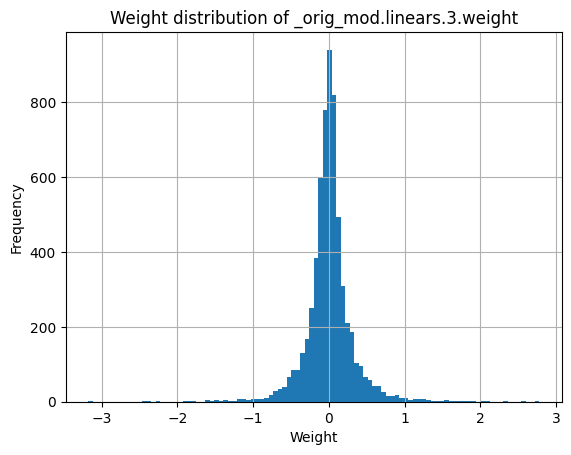

_orig_mod.linears.3.bias
Parameter containing:
tensor([-1.1021e-01,  2.2357e-01, -6.0702e-04,  8.3505e-02, -2.0245e-02,
        -5.3905e-02, -6.4023e-02, -1.6141e-02,  2.5236e-01,  3.1251e-02,
        -3.8636e-01, -7.5376e-02, -6.1556e-02, -6.5111e-02, -5.1112e-02,
         1.2928e-01,  1.8730e-01,  7.1235e-02,  9.2653e-02, -3.7411e-02,
        -5.2290e-02, -9.9818e-02,  4.9611e-01,  2.4065e-04, -6.4705e-02,
        -9.6415e-02, -7.8710e-02, -8.7408e-03, -1.1059e-01,  1.2251e-01,
        -1.1531e-01, -4.2724e-02, -2.6943e-02, -5.3836e-02, -6.3334e-02,
         3.0894e-02,  9.5852e-02,  5.5161e-02, -1.6499e-01, -5.1621e-02,
        -4.5885e-02, -6.7358e-02,  3.0902e-02, -2.0063e-01,  1.3576e-01,
        -4.8916e-02, -7.1235e-02, -6.0133e-02, -9.9215e-02, -1.3954e-01,
         3.8960e-01,  2.6562e-03, -2.4504e-02, -5.1022e-02, -6.1827e-02,
        -1.7047e-01], requires_grad=True)
_orig_mod.final.weight
Parameter containing:
tensor([[-2.0287e-01,  1.9398e-01, -1.8160e-01,  2.8119e-01, -2

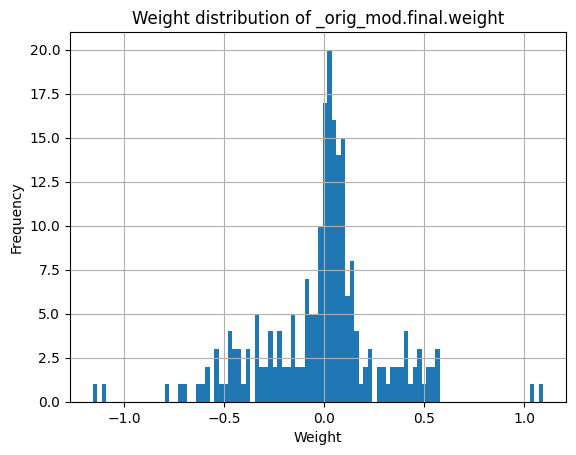

_orig_mod.final.bias
Parameter containing:
tensor([0.0829], requires_grad=True)


In [18]:
for name, param in model.named_parameters():
    print(name)
    print(param)

    if 'weight' in name:
        weights = param.data.cpu().numpy().flatten()
        print(len(weights))
        plt.figure()
        plt.hist(weights, bins=100)
        plt.title(f"Weight distribution of {name}")
        plt.xlabel("Weight")
        plt.ylabel("Frequency")
        plt.grid(True)
        plt.show()

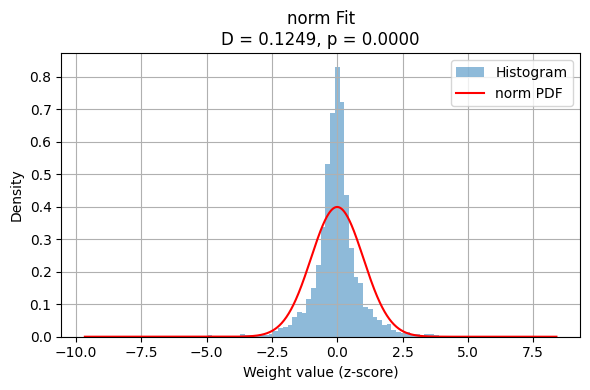

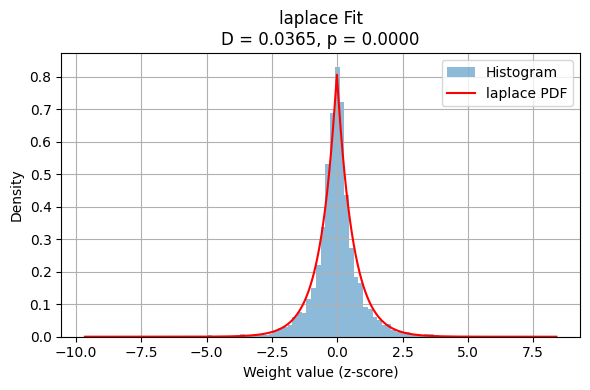

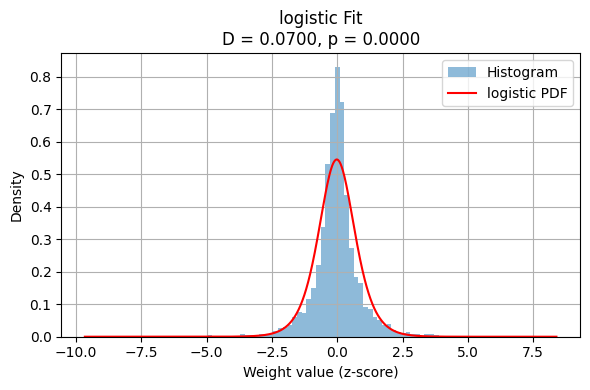

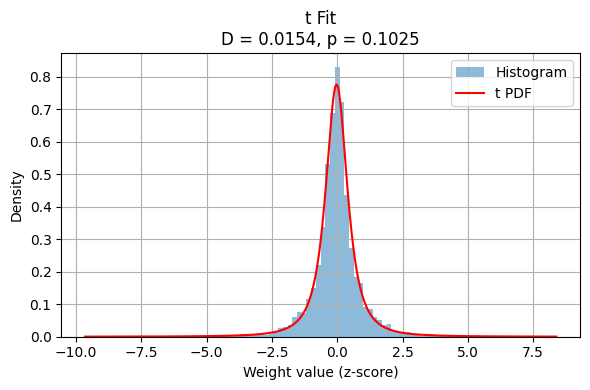

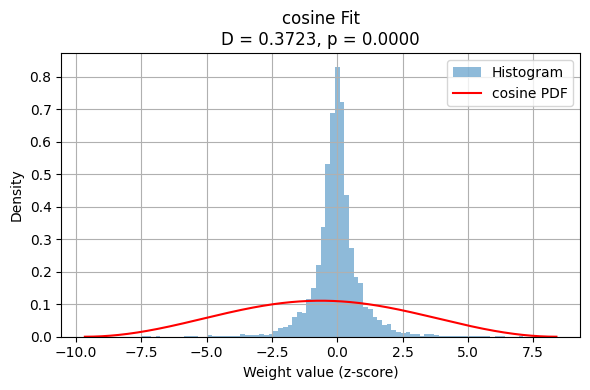

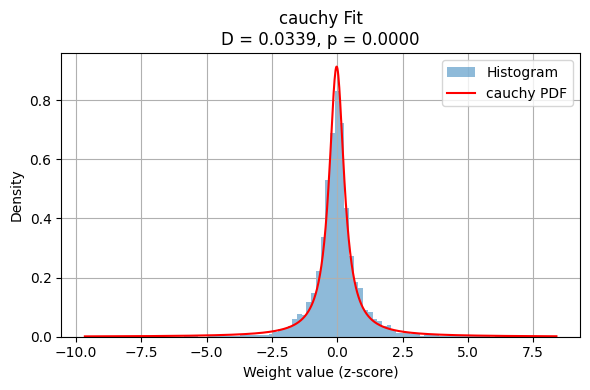

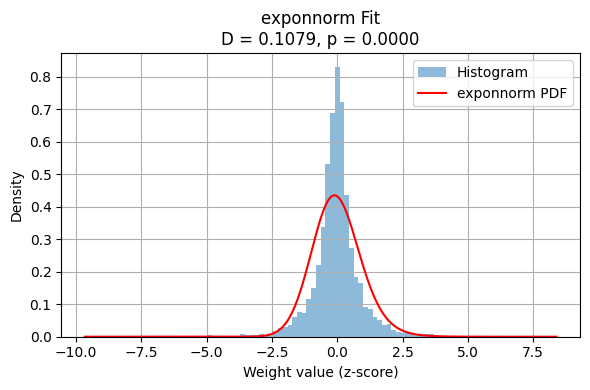

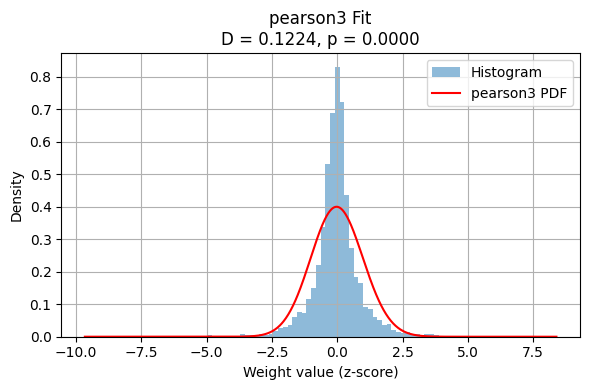

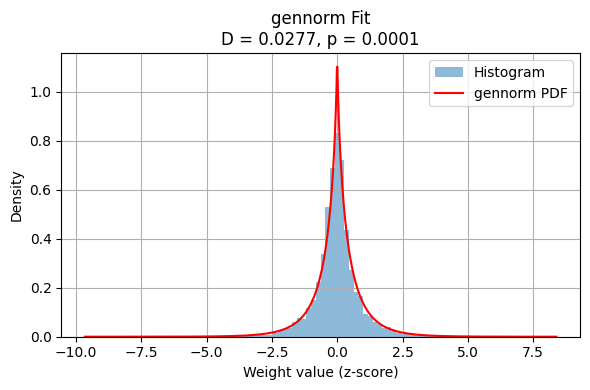

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

weights = model._orig_mod.linears[3].weight.detach().cpu().numpy().flatten()
weights = stats.zscore(weights)

distributions = {
    "norm": stats.norm,
    "laplace": stats.laplace,
    "logistic": stats.logistic,
    "t": stats.t,
    "cosine": stats.cosine,
    "cauchy": stats.cauchy,
    "exponnorm": stats.exponnorm,
    "pearson3": stats.pearson3,
    "gennorm": stats.gennorm,
}

results = {}
x = np.linspace(min(weights), max(weights), 1000)

for name, dist in distributions.items():
    try:
        params = dist.fit(weights)
        D, p_value = stats.kstest(weights, dist.cdf, args=params)
        results[name] = {"D": D, "p_value": p_value}

        plt.figure(figsize=(6, 4))
        plt.hist(weights, bins=100, density=True, alpha=0.5, label="Histogram")
        pdf = dist.pdf(x, *params)
        plt.plot(x, pdf, 'r-', label=f'{name} PDF')
        plt.title(f"{name} Fit\nD = {D:.4f}, p = {p_value:.4f}")
        plt.xlabel("Weight value (z-score)")
        plt.ylabel("Density")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        results[name] = {"D": None, "p_value": None, "error": str(e)}
        print(f"{name:12s} | Fit failed: {e}")


Goodness-of-fit test results:
levy_stable  | D = 0.0317 | p = 0.0000


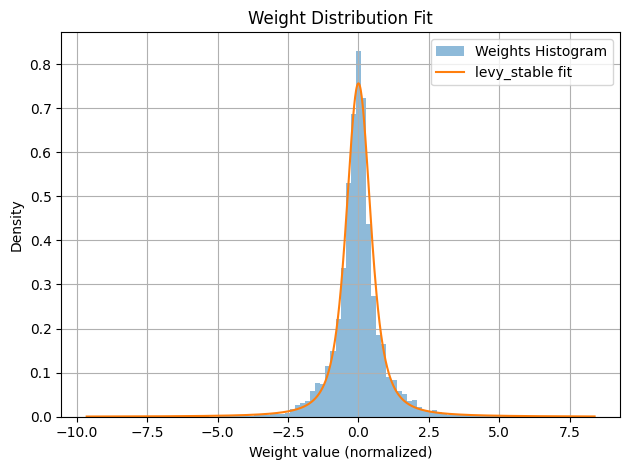

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

weights = model._orig_mod.linears[3].weight.detach().cpu().numpy().flatten()
weights = stats.zscore(weights)

distributions = {
    "levy_stable": stats.levy_stable
}

results = {}

for name, dist in distributions.items():
    try:
        params = dist.fit(weights, floc=0, fbeta=0)
        D, p_value = stats.kstest(weights, dist.cdf, args=params)
        results[name] = {"D": D, "p_value": p_value, "params": params}
    except Exception as e:
        results[name] = {"D": None, "p_value": None, "error": str(e)}

print("Goodness-of-fit test results:")
for name, result in results.items():
    if result["D"] is not None:
        print(f"{name:12s} | D = {result['D']:.4f} | p = {result['p_value']:.4f}")
    else:
        print(f"{name:12s} | Fit failed: {result['error']}")

plt.hist(weights, bins=100, density=True, alpha=0.5, label="Weights Histogram")
x = np.linspace(min(weights), max(weights), 1000)

for name, dist in distributions.items():
    result = results.get(name)
    if result and result["D"] is not None:
        try:
            params = result["params"]
            pdf = dist.pdf(x, *params)
            plt.plot(x, pdf, label=f"{name} fit")
        except Exception as e:
            print(f"PDF plot failed for {name}: {e}")

plt.title("Weight Distribution Fit")
plt.xlabel("Weight value (normalized)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()